In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\temp2.8.csv"
df=pd.read_csv(csv_path)

In [2]:
df=df.drop(columns=['row_idx', 'Complexity P', 'Complexity S','White Complexity Sum', 'Black Complexity Sum','Stage Analysis'])
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'\s+', '_', regex=True)
)
df.columns

Index(['UID', 'White', 'Black', 'White_CP_Loss', 'White_Accuracy',
       'Black_CP_Loss', 'Black_Accuracy', 'Evaluation', 'ComplexityE',
       'Judgments', 'White_Blunders', 'White_Mistakes', 'White_Inaccuracies',
       'Black_Blunders', 'Black_Mistakes', 'Black_Inaccuracies',
       'Complexity_E1', 'Complexity_E2', 'Complexity_E3', 'Complexity_E4',
       'Complexity_E5'],
      dtype='object')

In [3]:
df.head()

,UID,White,Black,White_CP_Loss,White_Accuracy,Black_CP_Loss,Black_Accuracy,Evaluation,ComplexityE,Judgments,...,White_Mistakes,White_Inaccuracies,Black_Blunders,Black_Mistakes,Black_Inaccuracies,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,21.9,95.8,52.1,90.7,"0.33,0.36,0.30,0.44,0.32,0.39,0.40,0.39,0.32,0...","33,36,30,44,32,39,40,39,32,50,42,66,56,70,58,8...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccu...",...,1,2,2,1,1,"36,33,36,30,44,32,39,40,39,32,50,42,66,56,70,5...","34,34,33,63,35,37,38,47,23,46,40,55,58,57,55,6...","31,34,27,66,26,67,36,60,17,49,29,55,48,65,29,7...","25,42,25,78,21,71,34,67,12,52,26,57,35,74,28,8...","16,48,20,79,21,72,25,83,11,53,18,62,28,90,27,9..."
1,35,AradNazari,Andre Bold,23.5,96.5,58.1,91.2,"0.28,0.37,0.39,0.36,0.18,0.14,0.36,0.42,0.40,0...","28,37,39,36,18,14,36,42,40,35,37,41,35,35,34,3...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,0,1,2,1,2,"31,28,37,39,36,18,14,36,42,40,35,37,41,35,35,3...","30,30,33,40,35,93,-22,36,2,41,19,76,29,262,-46...","28,31,27,41,32,141,-55,39,-12,42,1,80,20,276,-...","23,31,27,43,28,141,-67,47,-22,52,-13,92,5,345,...","12,50,26,45,16,180,-85,48,-51,52,-19,119,-3,38..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,36.5,89.7,17.4,94.4,"0.29,0.59,0.33,0.43,0.11,0.17,0.06,0.19,0.05,0...","29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,27,1...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inac...",...,0,5,0,0,2,"25,29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,2...","21,31,44,44,29,29,10,9,16,17,0,5,11,13,7,13,19...","20,31,40,55,14,36,8,12,3,17,-4,11,11,14,3,14,1...","13,32,33,60,9,41,8,23,0,19,-7,12,8,19,3,16,16,...","10,54,22,64,9,46,8,29,0,21,-18,17,8,22,3,18,10..."
3,37,Bartosz Przybylski,Joseph Ryan,33.2,92.4,71.0,87.5,"0.22,0.39,0.36,0.51,0.42,0.48,0.37,0.44,0.28,0...","22,39,36,51,42,48,37,44,28,26,37,66,66,64,71,5...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,0,1,2,2,1,"29,22,39,36,51,42,48,37,44,28,26,37,66,66,64,7...","25,23,33,37,43,53,26,37,39,28,21,58,-8,66,49,9...","21,27,21,41,33,59,22,38,26,29,0,60,-23,69,49,1...","13,28,19,47,32,67,15,38,0,31,-22,80,-41,104,47...","7,48,10,51,25,68,1,39,-7,35,-25,87,-57,111,40,..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,26.9,92.7,38.5,89.6,"0.31,0.28,0.28,0.36,0.30,0.39,0.39,0.39,0.31,0...","31,28,28,36,30,39,39,39,31,35,31,30,15,27,20,2...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,3,1,1,3,4,"35,31,28,28,36,30,39,39,39,31,35,31,30,15,27,2...","32,32,27,30,29,33,26,210,35,33,20,32,25,114,23...","20,32,15,35,25,35,23,212,30,36,17,35,23,398,22...","17,33,12,50,22,39,16,215,23,37,16,35,16,519,15...","17,43,6,60,16,40,15,229,22,43,13,37,12,521,13,..."


In [5]:
MISSING = '__MISSING__'
def split_with_missing_marker(x, marker='__MISSING__'):
    if not isinstance(x, str):
        return x

    tokens = x.split(',')
    return [t if t.strip() != '' else marker for t in tokens]

def parse_chess_data(df):
    list_cols = [
        'Judgments',
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
    ]

    # 1️ 复杂度列：只 split + 标记缺失，不转 float
    for col in list_cols:
        if col != 'Judgments':
            df[col] = df[col].apply(
                lambda x: split_with_missing_marker(x, marker=MISSING)
                if isinstance(x, str) else x
            )

    # 2️ Judgments 单独处理（它不涉及 float）
    df['Judgments'] = df['Judgments'].apply(
        lambda x: x.split(',') if isinstance(x, str) else x
    )

    return df


df=parse_chess_data(df)
df.head()

,UID,White,Black,White_CP_Loss,White_Accuracy,Black_CP_Loss,Black_Accuracy,Evaluation,ComplexityE,Judgments,...,White_Mistakes,White_Inaccuracies,Black_Blunders,Black_Mistakes,Black_Inaccuracies,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,21.9,95.8,52.1,90.7,"0.33,0.36,0.30,0.44,0.32,0.39,0.40,0.39,0.32,0...","[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,2,2,1,1,"[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,23.5,96.5,58.1,91.2,"0.28,0.37,0.39,0.36,0.18,0.14,0.36,0.42,0.40,0...","[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,1,2,1,2,"[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,36.5,89.7,17.4,94.4,"0.29,0.59,0.33,0.43,0.11,0.17,0.06,0.19,0.05,0...","[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,5,0,0,2,"[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,33.2,92.4,71.0,87.5,"0.22,0.39,0.36,0.51,0.42,0.48,0.37,0.44,0.28,0...","[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,1,2,2,1,"[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,26.9,92.7,38.5,89.6,"0.31,0.28,0.28,0.36,0.30,0.39,0.39,0.39,0.31,0...","[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,3,1,1,3,4,"[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


In [8]:
MISSING = '__MISSING__'

complexity_cols = [
    'ComplexityE', 'Complexity_E1', 'Complexity_E2',
    'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
]

total_missing = 0

for col in complexity_cols:
    total_missing += df[col].apply(
        lambda x: x.count(MISSING) if isinstance(x, list) else 0
    ).sum()

total_missing

np.int64(1000249)

In [9]:
df.shape

(104103, 21)

In [10]:
missing_by_col = {}

for col in df.columns:
    missing_by_col[col] = df[col].apply(
        lambda x: sum(1 for i in x if i == '__MISSING__') if isinstance(x, list) else 0
    ).sum()

missing_by_col

{'UID': np.int64(0),
 'White': np.int64(0),
 'Black': np.int64(0),
 'White_CP_Loss': np.int64(0),
 'White_Accuracy': np.int64(0),
 'Black_CP_Loss': np.int64(0),
 'Black_Accuracy': np.int64(0),
 'Evaluation': np.int64(0),
 'ComplexityE': np.int64(0),
 'Judgments': np.int64(0),
 'White_Blunders': np.int64(0),
 'White_Mistakes': np.int64(0),
 'White_Inaccuracies': np.int64(0),
 'Black_Blunders': np.int64(0),
 'Black_Mistakes': np.int64(0),
 'Black_Inaccuracies': np.int64(0),
 'Complexity_E1': np.int64(0),
 'Complexity_E2': np.int64(66506),
 'Complexity_E3': np.int64(179086),
 'Complexity_E4': np.int64(311977),
 'Complexity_E5': np.int64(442680)}

In [11]:
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    Es=row['ComplexityE']
    E1s=row['Complexity_E1']
    E2s=row['Complexity_E2']
    E3s=row['Complexity_E3']
    E4s=row['Complexity_E4']
    E5s=row['Complexity_E5']

    judgments = row['Judgments']
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(E3s, list):
        E3s = [] 
    if not isinstance(E4s, list):
        E4s = []   
    if not isinstance(E5s, list):
        E5s = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = len(judgments)
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'E': Es[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'E3':E3s[i],
            'E4':E4s[i],
            'E5':E5s[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data
all_moves = []

for row in tqdm(df.itertuples(index=False), total=len(df)):
    moves = explode_chess_data(row._asdict())
    all_moves.extend(moves)

df_moves = pd.DataFrame(all_moves)
df_moves.head()

100%|██████████| 104103/104103 [00:03<00:00, 29957.36it/s]


,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0


check about the missing

In [14]:
from tqdm.auto import tqdm
tqdm.pandas()
def is_missing(x):
    return (x is None) or (isinstance(x, str) and x == '__MISSING__') or pd.isna(x)
cols_to_show = [
    'uid', 'Move_Idx', 'Player', 'Color',
    'E1', 'E2', 'E3', 'E4', 'E5'
]

df_E2_missing = df_moves[df_moves['E5'].progress_apply(is_missing)][cols_to_show]
#display(df_E2_missing.head(50))

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [15]:
df_moves[['E', 'E1', 'E2', 'E3', 'E4', 'E5']].map(type).value_counts()

E              E1             E2             E3             E4             E5           
<class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>    9086334
Name: count, dtype: int64

In [16]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0


In [17]:
numeric_cols = ['E', 'E1']

for col in numeric_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce')

In [18]:
#white E1-E   black E-E1
def safe_sub(a, b):
    try:
        a = float(a)
        b = float(b)
    except (TypeError, ValueError):
        return np.nan
    return a - b
df_moves['Δi'] = df_moves.apply(
    lambda row: safe_sub(row['E1'], row['E2']),
    axis=1
)
df_moves.head(20)
print(df_moves['Δi'].describe())

count    9.019828e+06
mean    -7.075734e-02
std      1.077608e+03
min     -1.999700e+04
25%     -1.200000e+01
50%      0.000000e+00
75%      1.200000e+01
max      1.999800e+04
Name: Δi, dtype: float64


# Δ （Decision Margin）
设在某一步走法决策中，定义核心参数：
- $E_1$：最优走法的评估值
- $E_k$：第 $k$ 优走法的评估值，$k \in \{2,3,4,5\}$
- $w_k$：第 $k$ 优走法对应的权重，固定为：

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

记**存在的备选走法集合**为：
$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## 白方走法（White move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 黑方走法（Black move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 特殊情况（Special case）
若 $\mathcal{K} = \varnothing$（仅存在最优走法 $E_1$，无任何备选走法），定义：
$$
\Delta = 0
$$

## 注意事项（Notes）
1. 仅使用**连续存在**的 $E_2, E_3, \dots$，一旦某一 $E_k$ 缺失，后续所有项均不再参与计算；
2. 实际计算中，对本次参与运算的权重进行**归一化**处理；
3. 白方/黑方仅影响 $\Delta$ 的**符号方向**，不改变其数值尺度。

In [19]:
def compute_delta(row):
    Ei_cols=['E2', 'E3', 'E4', 'E5']
    color = row['Color']
    weights={'E2':0.4, 'E3':0.3, 'E4':0.2, 'E5':0.1}
    total_weight = 0.0
    E1 = row['E1']
    if pd.isna(E1): return np.nan

    delta = 0.0
    used_any = False

    for col in Ei_cols:
        Ei = row[col]
        try:
            Ei = float(Ei)
        except (TypeError, ValueError):
            break
        
        if pd.isna(Ei):
            break
        w =weights[col]
        total_weight += w
        if color =='White':
            delta += w*(E1 - Ei)
        else:
            delta += w*(Ei - E1)
        used_any = True

    if not used_any:
        return 0.0
    
    return delta/total_weight


df_moves['Δ'] = df_moves.progress_apply(compute_delta, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [20]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,2.0,6.5
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,-1.0,4.0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,3.0,7.7
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,-33.0,38.5
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,9.0,15.9


In [21]:
elo_info=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'] )
elo_info=elo_info[['uid','player', 'My_Elo']].rename(columns={'My_Elo':'ELO'})
elo_info=elo_info.set_index(['uid', 'player'])['ELO']
df_moves = df_moves.merge(
    elo_info,
    left_on=['uid', 'Player'],   # df_moves 中的列
    right_on=['uid', 'player'],      # elo_info 中的列
    how='left'
)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,2.0,6.5,2802
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,-1.0,4.0,2463
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,3.0,7.7,2802
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,-33.0,38.5,2463
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,9.0,15.9,2802


In [22]:
def elo_group(elo):
    if elo < 2400:
        return 'Low (<2400)'
    elif 2400<= elo < 2800:
        return 'Mid (2400-2799)'
    else:
        return 'Top (>=2800)'

df_moves['ELO_Group'] = df_moves['ELO'].apply(elo_group)
df_moves['ELO_Group'].value_counts(normalize=True)

ELO_Group
Mid (2400-2799)    0.571448
Low (<2400)        0.243949
Top (>=2800)       0.184603
Name: proportion, dtype: float64

In [23]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, left_on=['uid', 'Move_Idx'],   # df_moves 的列名
    right_on=['Game_ID', 'Move_Idx'],  # df_forced_expanded 的列名
    how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)
df_moves['Is_Forced'].value_counts()
df_moves = df_moves.drop(columns=['Game_ID'])

In [24]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)

In [25]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,2.0,6.5,2802,Top (>=2800),0,1
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,-1.0,4.0,2463,Mid (2400-2799),0,1
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,3.0,7.7,2802,Top (>=2800),0,1
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,-33.0,38.5,2463,Mid (2400-2799),0,1
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,9.0,15.9,2802,Top (>=2800),0,1


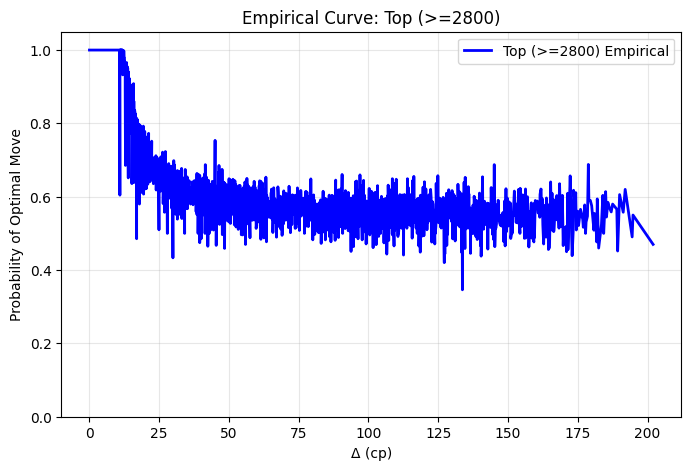

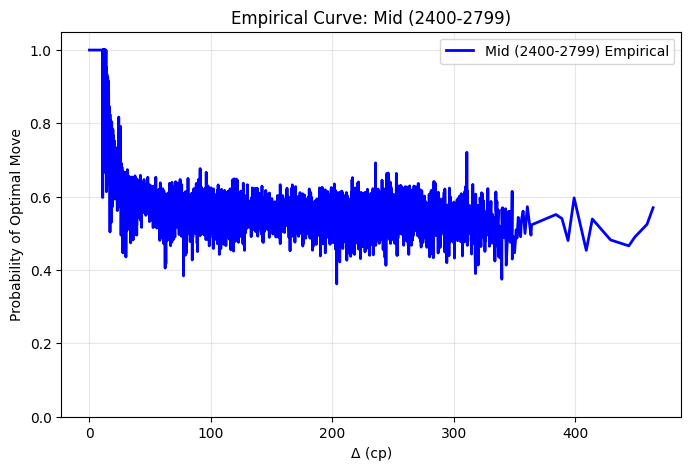

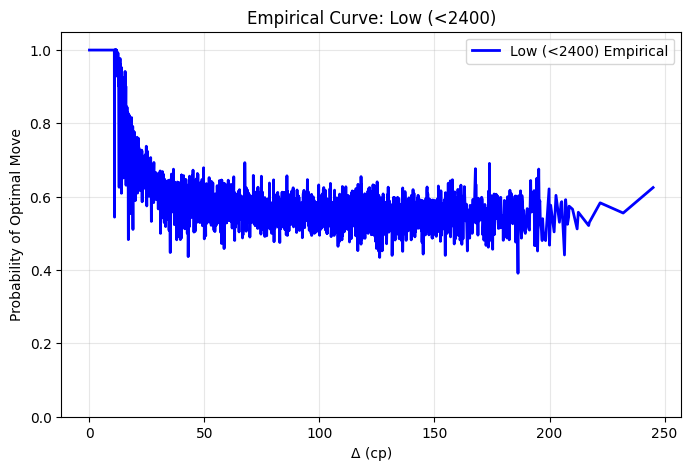

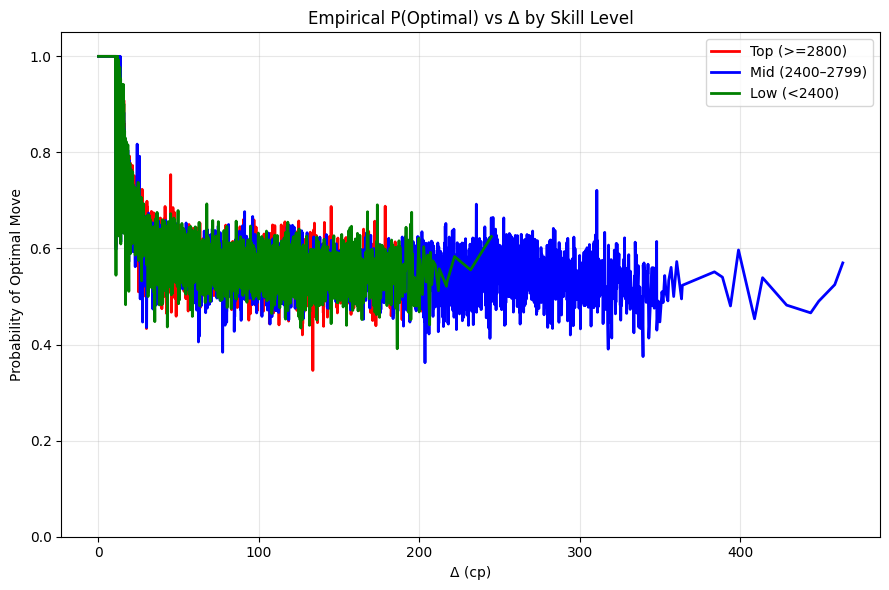

Top 组: A=0.528, 0.73A=0.385, Δ0≈133.7
Mid 组: A=0.530, 0.73A=0.387, Δ0≈203.6


TypeError: unsupported format string passed to NoneType.__format__

In [42]:
def empirical_curve(df, group_name, delta_max=1000, show_plot=True):
    group_df = df[(df['ELO_Group']==group_name) & (df['Is_Forced']==0)]
    
    # 只保留 Δ 在 1~delta_max 之间
    group_df = group_df[(group_df['Δ']>0) & (group_df['Δ']<=delta_max)]
    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    #只保留样本量大于100的点去画图
    valid_deltas = counts[counts >= 100].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    # 按 Δ 统计概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal':'P_Optimal'}, inplace=True)
    
    if show_plot:
        plt.figure(figsize=(8,5))
        plt.plot(prob_df['Δ'], prob_df['P_Optimal'], 'b-', lw=2, label=f'{group_name} Empirical')
        plt.xlabel('Δ (cp)')
        plt.ylabel('Probability of Optimal Move')
        plt.title(f'Empirical Curve: {group_name}')
        plt.ylim(0,1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    
    return prob_df

def plot_all_groups(top_curve, mid_curve, low_curve):
    plt.figure(figsize=(9,6))

    plt.plot(top_curve['Δ'], top_curve['P_Optimal'],
             color='red', lw=2, label='Top (>=2800)')
    plt.plot(mid_curve['Δ'], mid_curve['P_Optimal'],
             color='blue', lw=2, label='Mid (2400–2799)')
    plt.plot(low_curve['Δ'], low_curve['P_Optimal'],
             color='green', lw=2, label='Low (<2400)')

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title('Empirical P(Optimal) vs Δ by Skill Level')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_empirical_delta0_left(prob_df, target_prob):
    """prob_df: 包含 ['Δ', 'P_Optimal'] 的 DataFrame（已按 Δ 排序）, target_prob: 目标概率（如 0.73 * A）"""
    x = prob_df['Δ'].values
    y = prob_df['P_Optimal'].values
    
    # 只保留 y 单调上升的区间（避免尾部抖动）
    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    # 如果 target 超出范围，直接返回 None
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    # 插值反解
    delta0 = np.interp(target_prob, y, x)
    return delta0

def get_right_branch(prob_df):
    df = prob_df.sort_values('Δ').reset_index(drop=True)
    
    # 找到最小 P 的位置（下降 → 上升的转折点）
    idx_min = df['P_Optimal'].idxmin()
    
    # 只保留右半段
    return df.loc[idx_min:].reset_index(drop=True)

def get_empirical_delta0_right(prob_df, target_prob):
    right_df = get_right_branch(prob_df)
    
    x = right_df['Δ'].values
    y = right_df['P_Optimal'].values
    
    # 如果 target 不在范围内
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    return np.interp(target_prob, y, x)

def get_empirical_ceiling(df, group_name): 
    # 筛选出该组的大 Delta 数据 (比如 200 到 1000 cp) 
    high_delta_data = df[ (df['ELO_Group'] == group_name) & (df['Δ'] > 200) & (df['Δ'] <= 1000) ] 
    # 直接算 Is_Optimal 的平均值
    A_empirical = high_delta_data['Is_Optimal'].mean() 
    return A_empirical 

# 对所有组循环
groups = df_moves['ELO_Group'].unique()
all_prob_curves = {}
for g in groups:
    all_prob_curves[g] = empirical_curve(df_moves, g, delta_max=500, show_plot=True)
top_curve = all_prob_curves['Top (>=2800)']
mid_curve = all_prob_curves['Mid (2400-2799)']
low_curve = all_prob_curves['Low (<2400)']
plot_all_groups(top_curve, mid_curve, low_curve)


A_top = get_empirical_ceiling(df_moves, 'Top (>=2800)') 
A_mid = get_empirical_ceiling(df_moves, 'Mid (2400-2799)') 
A_low = get_empirical_ceiling(df_moves, 'Low (<2400)') 
A_073_top = A_top*0.73 
A_073_mid = A_mid*0.73 
A_073_low = A_low*0.73 

top_delta0 = get_empirical_delta0_right(top_curve, A_073_top)
mid_delta0 = get_empirical_delta0_right(mid_curve, A_073_mid)
low_delta0 = get_empirical_delta0_right(low_curve, A_073_low)

print(f"Top 组: A={A_top:.3f}, 0.73A={A_073_top:.3f}, Δ0≈{top_delta0:.1f}")
print(f"Mid 组: A={A_mid:.3f}, 0.73A={A_073_mid:.3f}, Δ0≈{mid_delta0:.1f}")
print(f"Low 组: A={A_low:.3f}, 0.73A={A_073_low:.3f}, Δ0≈{low_delta0:.1f}")


In [36]:
import os
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

white_sec
<class 'str'>    1017708
Name: count, dtype: int64
black_sec
<class 'str'>    1017708
Name: count, dtype: int64


In [37]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [38]:
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

white_sec
<class 'list'>    1017708
Name: count, dtype: int64
black_sec
<class 'list'>    1017708
Name: count, dtype: int64


In [39]:
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

second_list
<class 'list'>    1017708
Name: count, dtype: int64


In [40]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [41]:
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [43]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,2.0,6.5,2802,Top (>=2800),0,1,179.8
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,-1.0,4.0,2463,Mid (2400-2799),0,1,177.8
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,3.0,7.7,2802,Top (>=2800),0,1,178.5
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,-33.0,38.5,2463,Mid (2400-2799),0,1,178.7
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,9.0,15.9,2802,Top (>=2800),0,1,179.2


In [44]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time'],
      dtype='object')

In [45]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

Time_Group
Middle (70-170)           0.378831
Tense (15-70)             0.243047
Extremely Tense (0-15)    0.190858
Rich (>170)               0.187265
Name: proportion, dtype: float64

In [46]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,0,2.0,6.5,2802,Top (>=2800),0,1,179.8,Rich (>170)
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,0,-1.0,4.0,2463,Mid (2400-2799),0,1,177.8,Rich (>170)
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,0,3.0,7.7,2802,Top (>=2800),0,1,178.5,Rich (>170)
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,0,-33.0,38.5,2463,Mid (2400-2799),0,1,178.7,Rich (>170)
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,0,9.0,15.9,2802,Top (>=2800),0,1,179.2,Rich (>170)


# Re-darw by time group

正在处理: Time=Rich (>170), ELO=Top (>=2800), Samples=323161
正在处理: Time=Rich (>170), ELO=Mid (2400-2799), Samples=973315
正在处理: Time=Rich (>170), ELO=Low (<2400), Samples=405078
正在处理: Time=Middle (70-170), ELO=Top (>=2800), Samples=627346
正在处理: Time=Middle (70-170), ELO=Mid (2400-2799), Samples=1958895
正在处理: Time=Middle (70-170), ELO=Low (<2400), Samples=855941
正在处理: Time=Tense (15-70), ELO=Top (>=2800), Samples=393456
正在处理: Time=Tense (15-70), ELO=Mid (2400-2799), Samples=1261665
正在处理: Time=Tense (15-70), ELO=Low (<2400), Samples=553282
正在处理: Time=Extremely Tense (0-15), ELO=Top (>=2800), Samples=333400
正在处理: Time=Extremely Tense (0-15), ELO=Mid (2400-2799), Samples=998496
正在处理: Time=Extremely Tense (0-15), ELO=Low (<2400), Samples=402299


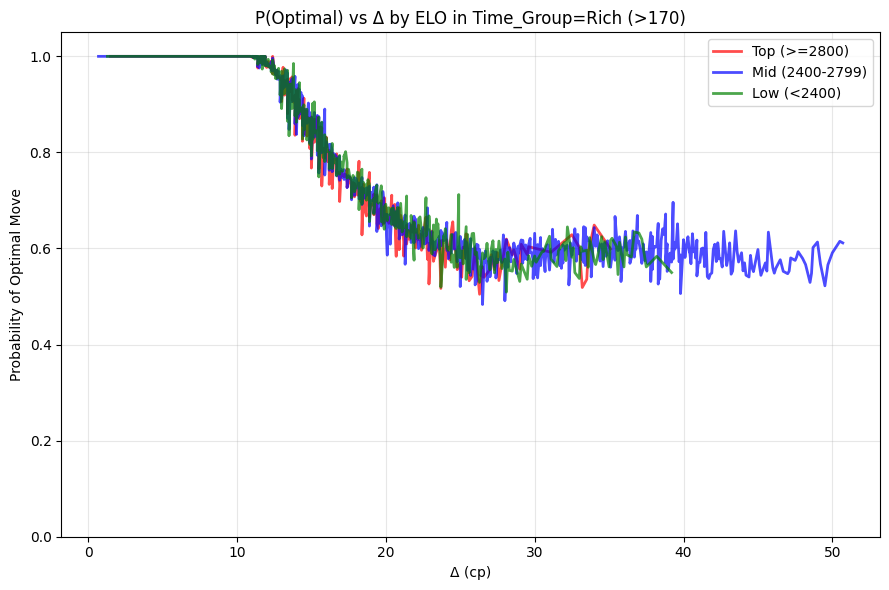

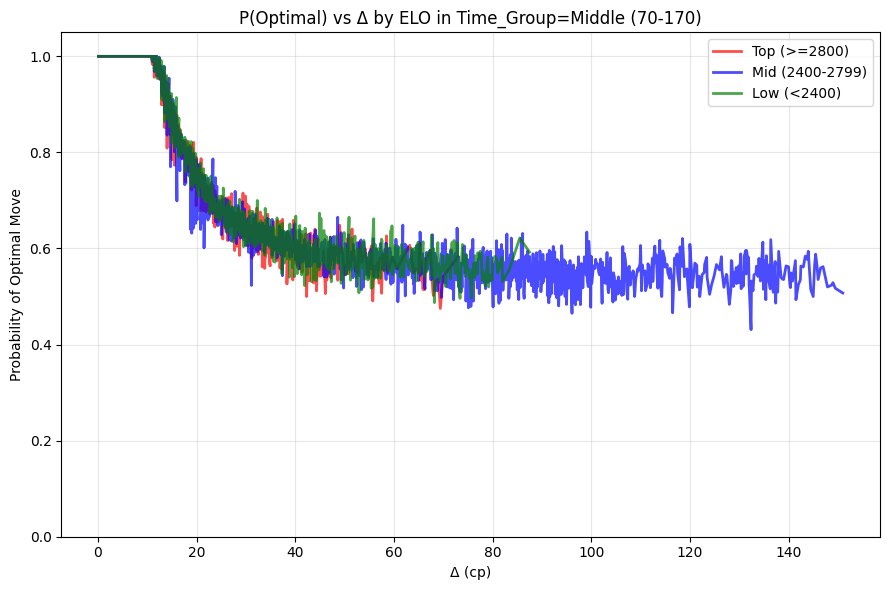

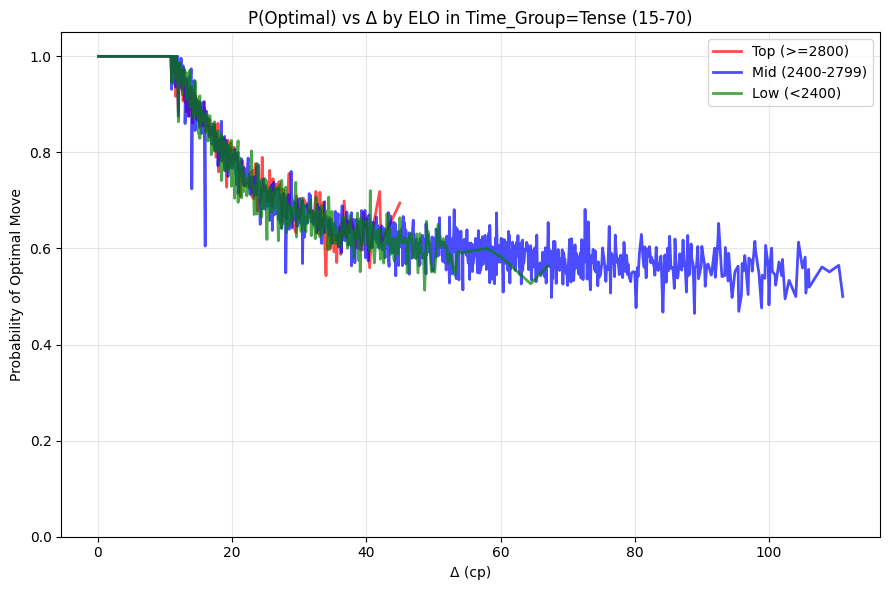

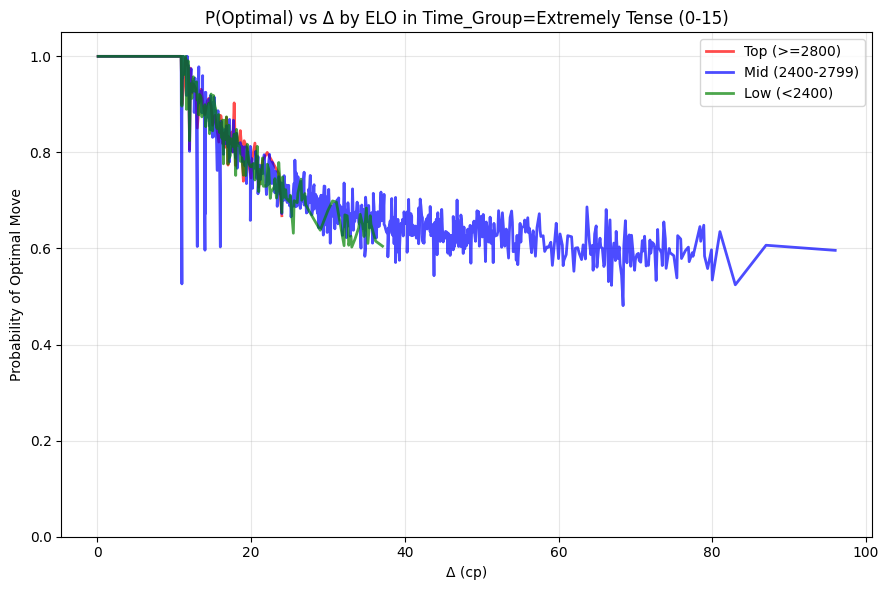

In [49]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 200].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 500,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(9,6))
    for e_group, color in zip(elo_groups, ['red', 'blue', 'green']):
        curve = all_prob_curves_time[t_group][e_group]
        if curve is not None and not curve.empty:
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2, color=color, alpha=0.7, label=e_group)
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO in Time_Group={t_group}')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

正在处理: Time=Extremely Tense (0-15), ELO=Top (>=2800), Samples=333400
正在处理: Time=Middle (70-170), ELO=Top (>=2800), Samples=627346
正在处理: Time=Rich (>170), ELO=Top (>=2800), Samples=323161
正在处理: Time=Tense (15-70), ELO=Top (>=2800), Samples=393456


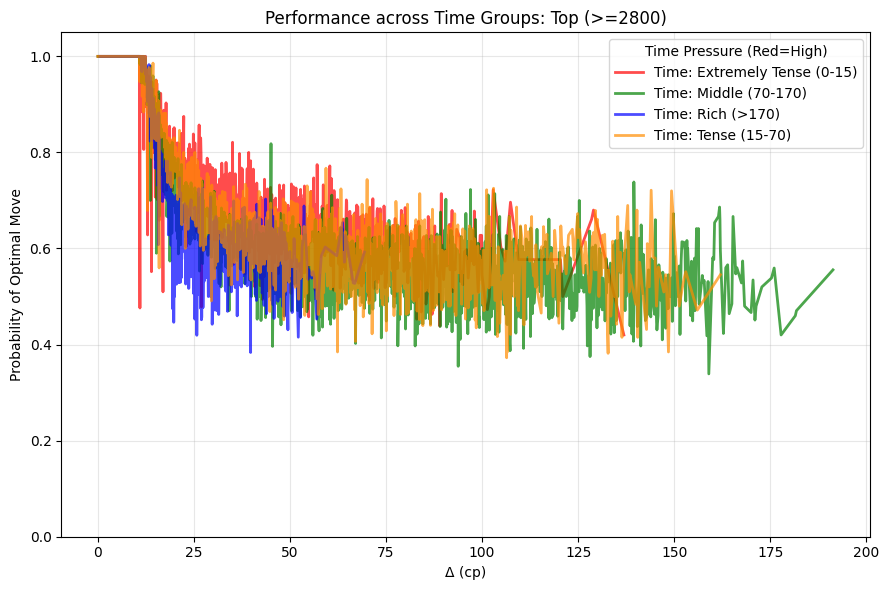

正在处理: Time=Extremely Tense (0-15), ELO=Mid (2400-2799), Samples=998496
正在处理: Time=Middle (70-170), ELO=Mid (2400-2799), Samples=1958895
正在处理: Time=Rich (>170), ELO=Mid (2400-2799), Samples=973315
正在处理: Time=Tense (15-70), ELO=Mid (2400-2799), Samples=1261665


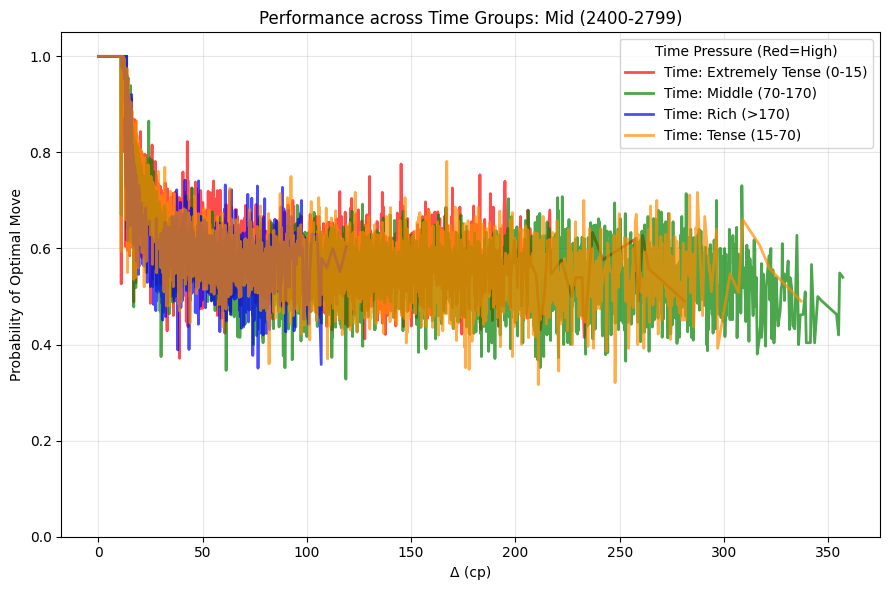

正在处理: Time=Extremely Tense (0-15), ELO=Low (<2400), Samples=402299
正在处理: Time=Middle (70-170), ELO=Low (<2400), Samples=855941
正在处理: Time=Rich (>170), ELO=Low (<2400), Samples=405078
正在处理: Time=Tense (15-70), ELO=Low (<2400), Samples=553282


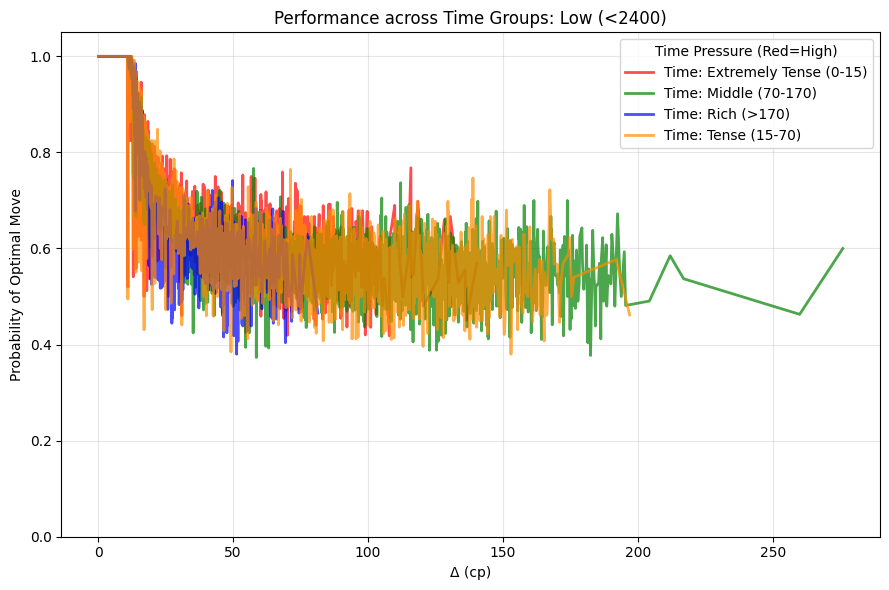

In [48]:
# 看不同elo组在不同时间压力情况下的表现情况
time_color_map = {
    'Extremely Tense (0-15)': 'red', 
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

for e_group in elo_groups:
    plt.figure(figsize=(9, 6))
    sorted_time_groups = sorted(time_groups) 
    
    for t_group in sorted_time_groups:
        # 获取该时间组和ELO组的子集
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        curve = all_prob_curves_time[t_group].get(e_group)
        
        if curve is not None and not curve.empty:
            # 从字典里取颜色，如果找不到就默认用灰色
            color = time_color_map.get(t_group, 'gray')
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2, alpha=0.7, color=color,label=f'Time: {t_group}')
    
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title="Time Pressure (Red=High)")
    plt.tight_layout()
    plt.show()